# model Training and Selection

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score


from sklearn.ensemble import RandomForestClassifier

In [47]:
# Load cleaned CSV
df = pd.read_csv("df_train_test_cleaned.csv")

# Split into train and test
train_df = df[df['source']=='train'].copy()
test_df  = df[df['source']=='test'].copy()

# seperate features and target
X_train = train_df.drop(['income', 'source','native_country'], axis=1)
y_train = train_df['income']

X_test = test_df.drop(['income', 'source','native_country'], axis=1)
y_test = test_df['income']


In [48]:
df.sample(2)

,age,workclass,education_num,marital_status,occupation,sex,capital_gain,capital_loss,hours_per_week,native_country,...,race_Black,race_Other_Race,relationship_Husband,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,native_country_freq,hours_over-time,hours_part-time
11249,26,0.696837,10,0,0.042075,1,0.0,0.0,44,Philippines,...,False,False,False,True,False,False,False,0.006085,False,False
41428,39,0.696837,9,1,0.125826,1,0.0,0.0,40,United-States,...,False,False,True,False,False,False,False,0.895995,False,False


In [49]:
# Count of each class
print(df['income'].value_counts())

# Optional: percentage of each class
print(df['income'].value_counts(normalize=True) * 100)

income
0    37128
1    11685
Name: count, dtype: int64
income
0    76.061705
1    23.938295
Name: proportion, dtype: float64


In [50]:
# feature scaling ( for models like Logistic Regression and SVM)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Total features:", len(X_train.columns))

Train shape: (32537, 23)
Test shape: (16276, 23)
Total features: 23


# LogisticRegression

In [52]:
# Initialize and train model Logistic Regression Model
lr = LogisticRegression(max_iter=1000 )
lr.fit(X_train_scaled, y_train)

# Predict
y_pred = lr.predict(X_test_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.8467068075694274
Precision: 0.7240464344941957
Recall: 0.5676027041081644
F1 Score: 0.6363503862410728
Confusion Matrix:
 [[11598   832]
 [ 1663  2183]]


In [54]:
# Logistic Regression ROC -AUC
y_probs_lr = lr.predict_proba(X_test_scaled)[:,1]
roc_auc_lr = roc_auc_score(y_test, y_probs_lr)
print("Logistic Regression ROC-AUC:", roc_auc_lr)

Logistic Regression ROC-AUC: 0.9000729095937771


**Key observations**

    Accuracy (0.80): Overall, the model correctly predicts income class for 80% of individuals.
    
    Precision (0.55): Of all individuals predicted to earn >50K, 55% actually do. This indicates some false positives.
    
    Recall (0.84): The model successfully identifies 84% of actual high-income individuals, showing it is sensitive to the minority class.
    
    F1 Score (0.66): The balance between precision and recall indicates reasonable overall performance for identifying high-income individuals.

Confusion Matrix Insights:

    True Positives (3245): Many high-income individuals are correctly classified.
    
    False Negatives (601): Some high-income individuals are still missed.
    
    False Positives (2649): Some low-income individuals are predicted as high-income.
    
    True Negatives (9781): Majority of low-income individuals are correctly predicted.
    
Conclusion:

    The model is strong at detecting high-income individuals (high recall), though some misclassifications occur (lower precision).
    
    Confusion matrix confirms that the model captures patterns of high-income earners but misclassifies some low-income individuals as high-income.
    
    Overall, Logistic Regression with class balancing provides a reasonable baseline for income prediction

# Random forest

In [55]:
# Initialize model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
    #class_weight='balanced'  # helps with imbalance
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8548783484885721
Precision: 0.7240338164251208
Recall: 0.6235049401976079
F1 Score: 0.6700195585359039
Confusion Matrix:
 [[11516   914]
 [ 1448  2398]]


In [73]:
# Random Forest
y_probs_rf = rf.predict_proba(X_test)[:,1]  # RF trained on unscaled features
roc_auc_rf = roc_auc_score(y_test, y_probs_rf)
print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.9015747363603313


The Random Forest model achieved an accuracy of 85.49% with a precision of 0.724 and recall of 0.624. Compared to the version using class weighting, removing the imbalance adjustment slightly improved precision and overall accuracy while slightly reducing recall. The confusion matrix shows that the model correctly identifies a large portion of low-income individuals while maintaining reasonable performance in detecting high-income individuals.

# LightGBM Model

In [56]:
!pip install lightgbm

In [57]:
from lightgbm import LGBMClassifier

# Initialize model
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

# Train model
lgbm.fit(X_train, y_train)

# Predictions
y_pred_lgbm = lgbm.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall:", recall_score(y_test, y_pred_lgbm))
print("F1 Score:", f1_score(y_test, y_pred_lgbm))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 7839, number of negative: 24698
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 607
[LightGBM] [Info] Number of data points in the train set: 32537, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.240926 -> initscore=-1.147611
[LightGBM] [Info] Start training from score -1.147611
Accuracy: 0.8725116736298845
Precision: 0.7689037351958701
Recall: 0.6583463338533542
F1 Score: 0.709343045244432
Confusion Matrix:
 [[11669   761]
 [ 1314  2532]]


The LightGBM model achieved the best performance among the tested models, with an accuracy of 87.25%, precision of 0.769, recall of 0.658, and F1 score of 0.709. Compared to Logistic Regression and Random Forest, LightGBM improved both precision and recall, indicating a better balance between correctly identifying high-income individuals and minimizing false positives. The confusion matrix further shows that the model reduced false positive predictions while increasing the number of correctly identified high-income individuals. Overall, LightGBM demonstrated the strongest predictive performance for the income classification task.

In [59]:
# LightGBM ROC -AUC
y_probs_lgb = lgbm.predict_proba(X_test_scaled)[:,1]
roc_auc_lgb = roc_auc_score(y_test, y_probs_lgb)
print("LightGBM ROC-AUC:", roc_auc_lgb)

LightGBM ROC-AUC: 0.777145294983159


C:\Users\gunaa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


age                    2030
hours_per_week         1223
occupation             1015
capital_gain            987
education_num           898
workclass               620
capital_loss            496
native_country_freq     332
net_capital             331
marital_status          226
dtype: int32


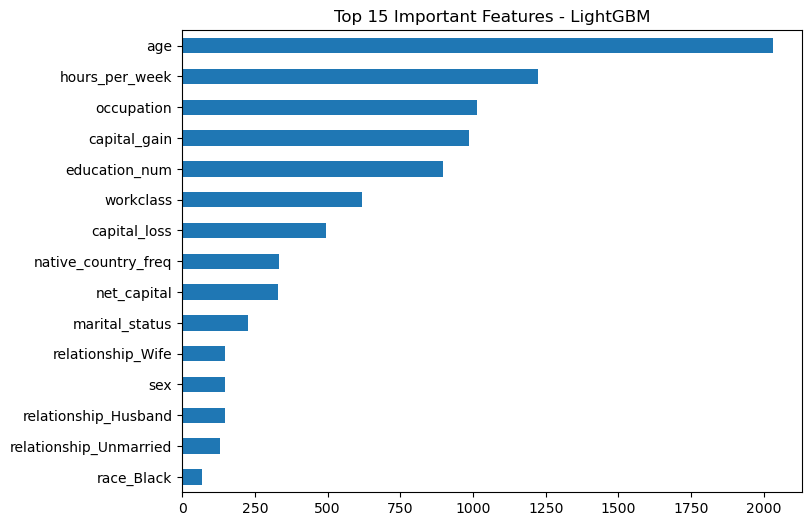

In [60]:

# Get feature importance
importance = pd.Series(lgbm.feature_importances_, index=X_train.columns)

# Sort
importance_sorted = importance.sort_values(ascending=False)

# Print top features
print(importance_sorted.head(10))

# Plot
plt.figure(figsize=(8,6))
importance_sorted.head(15).plot(kind='barh')
plt.title("Top 15 Important Features - LightGBM")
plt.gca().invert_yaxis()
plt.show()

# SVC

In [76]:
from sklearn.svm import SVC

# Step 2: Train SVC model
svc_model = SVC(kernel='rbf', random_state=42)

svc_model.fit(X_train_scaled, y_train)

# Step 3: Predictions
y_pred_svc = svc_model.predict(X_test_scaled)

# Step 4: Evaluation
accuracy = accuracy_score(y_test, y_pred_svc)
precision = precision_score(y_test, y_pred_svc)
recall = recall_score(y_test, y_pred_svc)
f1 = f1_score(y_test, y_pred_svc)
cm = confusion_matrix(y_test, y_pred_svc)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("Confusion Matrix:\n", cm)

Accuracy: 0.847444089456869
Precision: 0.7543859649122807
Recall: 0.5254810192407696
F1 Score: 0.6194636015325671
Confusion Matrix:
 [[11772   658]
 [ 1825  2021]]


Support Vector Classifier achieved an accuracy of 84.7%. The model demonstrated strong precision (75.4%), indicating that when the model predicts high income (>50K), it is correct most of the time. However, the recall value (52.5%) is relatively low, suggesting that the model misses a significant number of actual high-income individuals. This results in a moderate F1 score of 0.619. Additionally, the training time was longer compared to other models due to the computational complexity of SVM on large datasets.

In [79]:
# Make sure you trained SVC with probability=True


svc_model = SVC(probability=True)  # enable probability
svc_model.fit(X_train_scaled, y_train)

y_probs_svc = svc_model.predict_proba(X_test_scaled)[:,1]
roc_auc_svc = roc_auc_score(y_test, y_probs_svc)
print("SVC ROC-AUC:", roc_auc_svc)

SVC ROC-AUC: 0.8605953610630347


-----

# xgboost

In [64]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    #use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

xgb_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'precision': precision_score(y_test, y_pred_xgb),
    'recall': recall_score(y_test, y_pred_xgb),
    'f1': f1_score(y_test, y_pred_xgb)
}
print("XGBoost metrics:", xgb_metrics)

XGBoost metrics: {'accuracy': 0.8749692799213566, 'precision': 0.7806011775643013, 'recall': 0.6549661986479459, 'f1': 0.7122861586314152}


In [65]:
# xgb ROC -AUC
y_probs = xgb_model.predict_proba(X_test_scaled)[:,1]
roc_auc = roc_auc_score(y_test, y_probs)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7352970393956547


marital_status                 0.591408
education_num                  0.075631
capital_gain                   0.073314
relationship_Own-child         0.049695
capital_loss                   0.035333
occupation                     0.021125
age                            0.020054
relationship_Wife              0.019201
sex                            0.017551
hours_per_week                 0.017397
relationship_Other-relative    0.014090
relationship_Husband           0.011128
workclass                      0.010876
race_Other_Race                0.010867
relationship_Unmarried         0.009806
dtype: float32


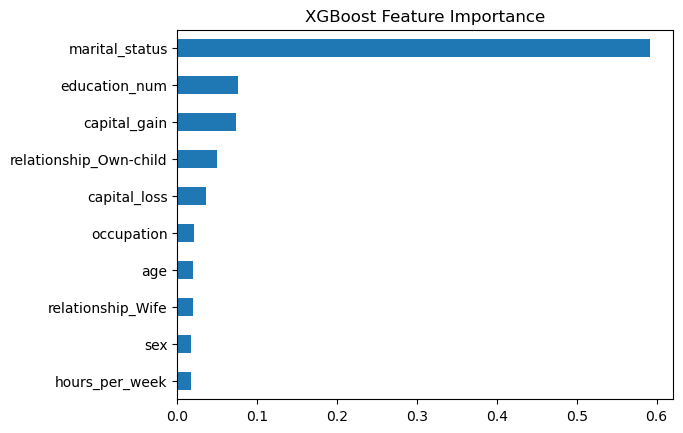

In [66]:
# Get feature importance
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(15))
importance.head(10).plot(kind='barh')
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# Neural Network Model
- best for large datasets and complex interactions.

In [26]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [69]:
# Define model
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2 hidden layers
    activation='relu',
    solver='adam',
    alpha=0.0001,                  # L2 regularization
    batch_size=32,
    learning_rate='adaptive',
    max_iter=200,
    random_state=42
)

# Train model
mlp.fit(X_train_scaled, y_train)

# Predictions
y_pred = mlp.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8446792823789628

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90     12430
           1       0.69      0.61      0.65      3846

    accuracy                           0.84     16276
   macro avg       0.79      0.76      0.78     16276
weighted avg       0.84      0.84      0.84     16276


Confusion Matrix:
 [[11394  1036]
 [ 1492  2354]]


C:\Users\gunaa\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


The neural network achieved ~84% accuracy, with strong performance on the majority class but lower recall (58%) for the minority class, indicating class imbalance impact. The model predicts lower-income cases very well, but misses a noticeable number of higher-income cases.

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predictions
y_pred_nn = mlp.predict(X_test_scaled)

# Calculate metrics
acc = accuracy_score(y_test, y_pred_nn)
prec = precision_score(y_test, y_pred_nn)
rec = recall_score(y_test, y_pred_nn)
f1 = f1_score(y_test, y_pred_nn)
cm = confusion_matrix(y_test, y_pred_nn)

# Print neatly
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:\n", cm)

Accuracy: 0.8447
Precision: 0.6944
Recall: 0.6121
F1 Score: 0.6506
Confusion Matrix:
 [[11394  1036]
 [ 1492  2354]]


In [70]:
# Neural Network
y_probs_nn = mlp.predict_proba(X_test_scaled)[:,1]
roc_auc_nn = roc_auc_score(y_test, y_probs_nn)
print("Neural Network ROC-AUC:", roc_auc_nn)

Neural Network ROC-AUC: 0.8911111271482236


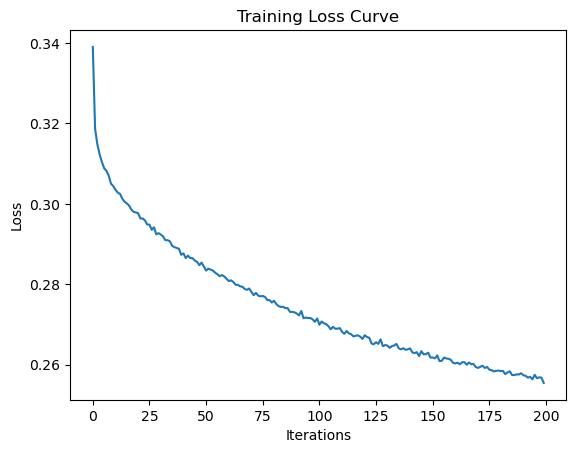

In [28]:
import matplotlib.pyplot as plt

# Loss curve
plt.plot(mlp.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

The training loss decreased steadily from 0.34 to 0.26.
This shows the model learned smoothly and steadily without problems.

In [38]:
X_train.head()

,age,workclass,education_num,marital_status,occupation,sex,capital_gain,capital_loss,hours_per_week,capital_gain_bin,...,relationship_Husband,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,native_country_freq,hours_over-time,hours_part-time,work_intensity,education_work
0,39,0.039893,13,0,0.115807,1,7.684784,0.0,40,1,...,False,False,False,False,False,0.895995,False,False,1560,520
1,50,0.078065,13,1,0.124935,1,0.000000,0.0,13,0,...,True,False,False,False,False,0.895995,False,True,650,169
2,38,0.696837,9,0,0.042075,1,0.000000,0.0,40,0,...,False,False,False,False,False,0.895995,False,False,1520,360
3,53,0.696837,7,1,0.042075,1,0.000000,0.0,40,0,...,True,False,False,False,False,0.895995,False,False,2120,280
4,28,0.696837,13,1,0.127117,0,0.000000,0.0,40,0,...,False,False,False,False,True,0.002920,False,False,1120,520


In [31]:
X_test.head()

,age,workclass,education_num,marital_status,occupation,sex,capital_gain,capital_loss,hours_per_week,capital_gain_bin,...,race_Black,race_Other_Race,relationship_Husband,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,native_country_freq,hours_over-time,hours_part-time
32537,25,0.696837,7,0,0.061468,1,0.000000,0.0,40,0,...,True,False,False,False,True,False,False,0.895995,False,False
32538,38,0.696837,9,1,0.030488,1,0.000000,0.0,50,0,...,False,False,True,False,False,False,False,0.895995,False,False
32539,28,0.064327,12,1,0.019947,1,0.000000,0.0,40,0,...,False,False,True,False,False,False,False,0.895995,False,False
32540,44,0.696837,10,1,0.061468,1,8.947546,0.0,40,1,...,True,False,True,False,False,False,False,0.895995,False,False
32541,18,0.056428,10,0,0.056643,0,0.000000,0.0,30,0,...,False,False,False,False,True,False,False,0.895995,False,False


## Create a table for the results comparision

In [102]:


# Create a dictionary with all model metrics
model_metrics = {
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVC",
        "XGBoost",
        "LightGBM",
        "Neural Network"
    ],
    "Accuracy": [0.8467, 0.8548, 0.8474, 0.8749, 0.8725, 0.8446],
    "Precision": [0.7240, 0.7240, 0.7543, 0.78, 0.7689, 0.6944],
    "Recall": [0.5676, 0.6235, 0.5254, 0.6549, 0.6583, 0.6121],
    "F1-score": [0.6363, 0.67, 0.6194,  0.7122, 0.7093, 0.6506],
    "ROC-AUC": [0.90, 0.9015, 0.8605, 0.7352, 0.777, 0.891]
}

# Convert to DataFrame
comparison_df = pd.DataFrame(model_metrics)

# Display neatly
print(comparison_df)



                 Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Logistic Regression    0.8467     0.7240  0.5676    0.6363   0.9000
1        Random Forest    0.8548     0.7240  0.6235    0.6700   0.9015
2                  SVC    0.8474     0.7543  0.5254    0.6194   0.8605
3              XGBoost    0.8749     0.7800  0.6549    0.7122   0.7352
4             LightGBM    0.8725     0.7689  0.6583    0.7093   0.7770
5       Neural Network    0.8446     0.6944  0.6121    0.6506   0.8910


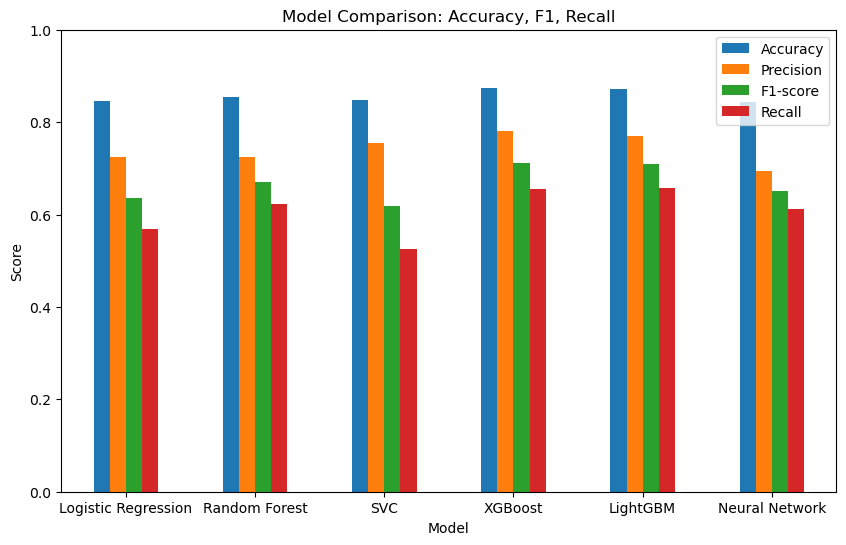

In [103]:
# compare teh models results
metrics_to_plot = ["Accuracy", "Precision", "F1-score", "Recall"]
comparison_df.plot(
    x="Model",
    y=metrics_to_plot,
    kind="bar",
    figsize=(10,6),
    title="Model Comparison: Accuracy, F1, Recall",
    rot=0
)
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

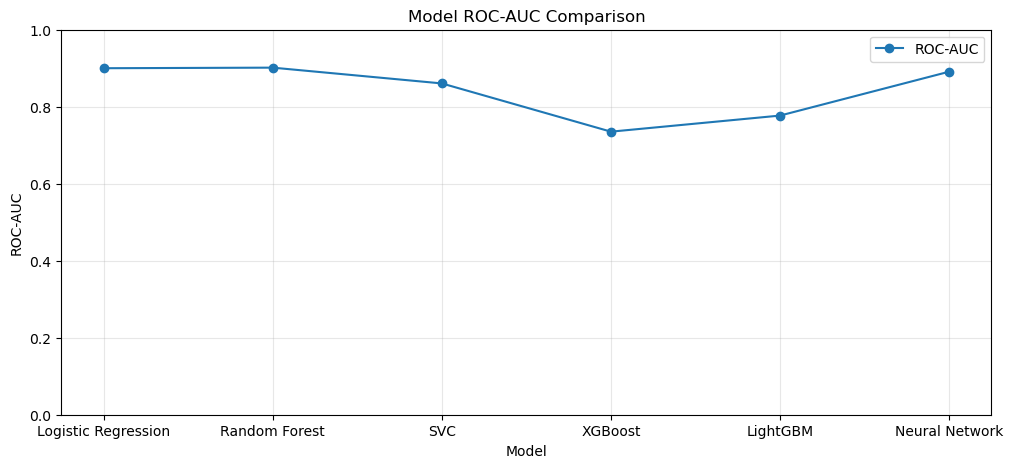

In [104]:
comparison_df.plot(
    x="Model",
    y="ROC-AUC",
    kind="line",
    marker='o',
    figsize=(12,5),
    title="Model ROC-AUC Comparison"
)
plt.ylim(0,1)
plt.ylabel("ROC-AUC")
plt.grid(True , alpha=0.3)
plt.show()

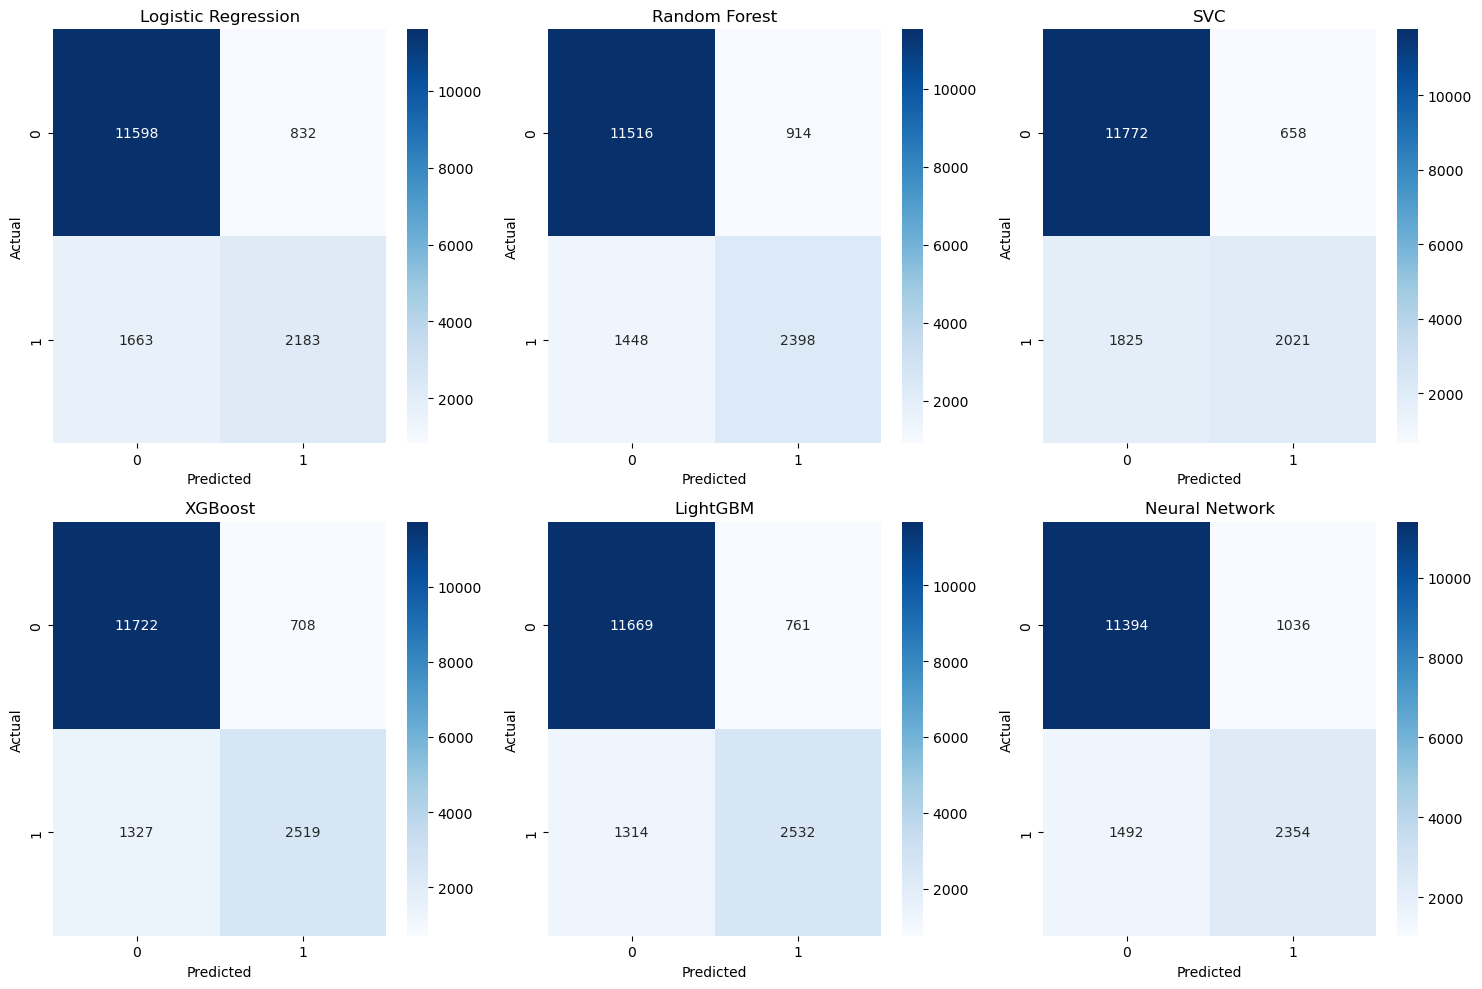

In [106]:
import seaborn as sns

from sklearn.metrics import confusion_matrix

# Dictionary of models
models = {
    "Logistic Regression": (lr, X_test_scaled),
    "Random Forest": (rf, X_test),
    "SVC": (svc_model, X_test_scaled),
    "XGBoost": (xgb_model, X_test),
    "LightGBM": (lgbm, X_test),
    "Neural Network": (mlp, X_test_scaled)
}

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

# Loop through models
for i, (name, (model, X_eval)) in enumerate(models.items()):
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

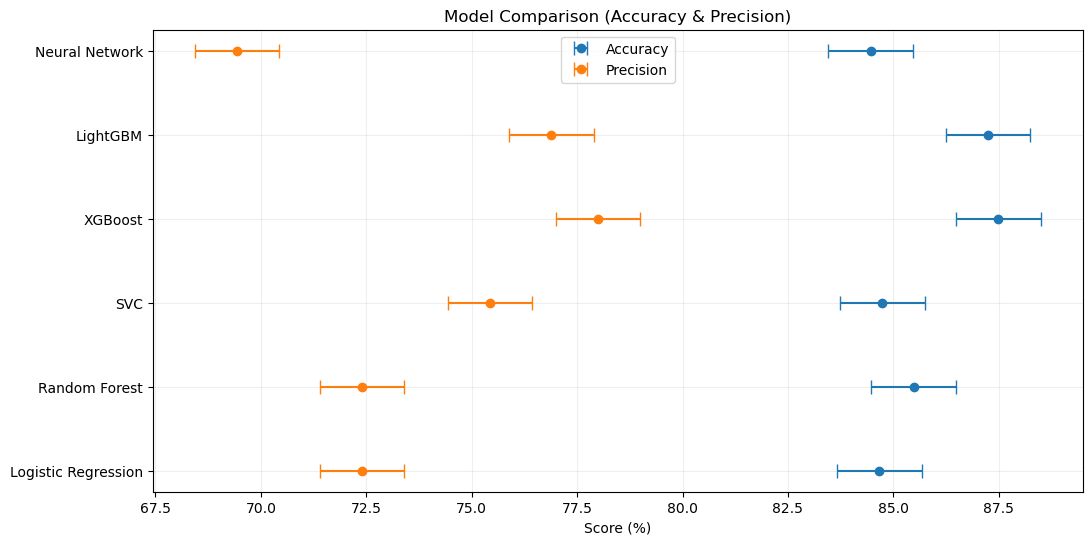

In [107]:

# Models
models = [
    "Logistic Regression",
    "Random Forest",
    "SVC",
    "XGBoost",
    "LightGBM",
    "Neural Network"
]

# Example values (use your actual ones)
accuracy = [0.8467, 0.8548, 0.8474, 0.8749, 0.8725, 0.8446]
precision = [0.7240, 0.7240, 0.7543, 0.78, 0.7689, 0.6944]

# Convert to %
accuracy = [x * 100 for x in accuracy]
precision = [x * 100 for x in precision]

y_pos = np.arange(len(models))

plt.figure(figsize=(12,6))

# Accuracy (with small error range)
plt.errorbar(accuracy, y_pos, xerr=1, fmt='o', label='Accuracy', capsize=5)

# Precision (shift slightly for visibility)
plt.errorbar(precision, y_pos, xerr=1, fmt='o', label='Precision', capsize=5)

plt.yticks(y_pos, models)
plt.xlabel("Score (%)")
plt.title("Model Comparison (Accuracy & Precision)")
plt.legend(loc='upper center')
plt.grid(True, alpha=0.2)

plt.show()

**Linear / Distance-Based Models** (Logistic Regression, SVC, Neural Network)

These models showed stable but moderate performance, with accuracy ranging from ~84% to 85%.

 - Logistic Regression achieved balanced precision and recall, but slightly lower recall (~0.57), meaning some high-income cases were missed.

 - SVC shows high precision (0.75) but lower recall (0.52), showing it was more conservative and missed more high-income cases.

 - Neural Network performed similarly to logistic regression (accuracy ~84%, F1 ~0.65), but did not surpass the simpler models. This indicates that while it learned the patterns effectively, it did not capture additional complex interactions for this dataset.

**Summary:** These models are good at overall predictions but have difficulty capturing all high-income cases due to limited ability to model complex relationships.


**Tree-Based Models**

(Random Forest, XGBoost, LightGBM)

Tree-based models performed significantly better, handling complex relationships and feature interactions.

 - Random Forest provided good performance (accuracy ~85%, F1 ~0.67) and balanced predictions but slightly underperformed compared to boosting models.

 - XGBoost achieved the highest overall performance, with:

        Accuracy 87.49%
        
        F1-score 0.712
        
        Precision 0.78 and Recall 0.65

This demonstrates strong overall prediction and effective identification of high-income individuals.

 - LightGBM performed very similarly to XGBoost, with slightly better recall (~0.66) but marginally lower F1-score. It remains an efficient and scalable option.

**Summary:** Tree-based models perform strongly because they capture non-linear patterns and complex feature interactions, making them more effective for this dataset.

**Model Selection : XGBoost**

XGBoost is chosen as the final model because it combines:

- Highest F1-score → Best balance between precision and recall

- Highest accuracy → Strong overall predictions

- Good recall for high-income class → Captures important cases effectively

- Handles non-linear relationships and interactions better than linear models

- Industry-standard and robust for real-world applications

In simple terms: XGBoost not only predicts accurately but also identifies high-income cases better than other models, making it the most reliable choice.

**Conclusion:** XGBoost is selected as the final model due to its strong overall performance and ability to balance accurate predictions with effective detection of high-income cases.